# Fast and Adaptive EMD (FAEMD) — 1D

**FAEMD** replaces the cubic-spline envelopes of classical EMD with
**order-statistics filters (OSF)** whose window length is chosen adaptively
from the spacing of local extrema (Bhuiyan / Thirumalaisamy & Ansell).

For multivariate 1-D signals the same window is estimated on the equal-weight
projection

$$
c_t = \sum_{i=1}^{n} H^{(i)}_t \,/\, \sqrt{n}
$$

and then applied to every channel — giving mode alignment without MEMD’s
directional projections.

**Reference**

> M. R. Thirumalaisamy, P. J. Ansell.  
> *Fast and Adaptive Empirical Mode Decomposition for Multidimensional,
Multivariate Signals.* IEEE SPL, 25(10):1550–1554, 2018.

MATLAB toolbox: FA-MVEMD (File Exchange 71270).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import FAEMD
from pysdkit._faemd.filter import mean_envelope_1d, filter_size1D
from pysdkit._faemd.extrema import extrema
from pysdkit.data import test_emd, test_multivariate_signal
from pysdkit.plot import plot_IMFs

print(FAEMD(max_imfs=3))


Fast and Adaptive Empirical Mode Decomposition (FAEMD)


## 1. Algorithm principles

1. **Combine** channels (if $n>1$): $c = \sum H_i/\sqrt{n}$.
2. **Detect extrema** on $c$; abort if fewer than 3 maxima or minima.
3. **Adaptive window** from extrema spacings — seven candidates $d_1\ldots d_7$
   (min/max of min/max spacings, their mean, median, mode); force odd and
   $\ge 3$.  `window_type` selects which candidate to use.
4. **Sift** each channel with the *same* window:
   - max/min envelopes via 1-D OSF;
   - pad + moving-average → mean envelope $m$;
   - $H \leftarrow H - m$.
5. Stop sifting when $\mathrm{MSE}(H_{\mathrm{new}}, H) < \tau$ for **all**
   channels (and at least two iterations).
6. Subtract the IMF from the residue and repeat.

## 2. Envelope construction (OSF vs intuition)

adaptive windows d1..d7 = [ 3.  3. 13. 13.  7.  3.  3.]
selected w = 3


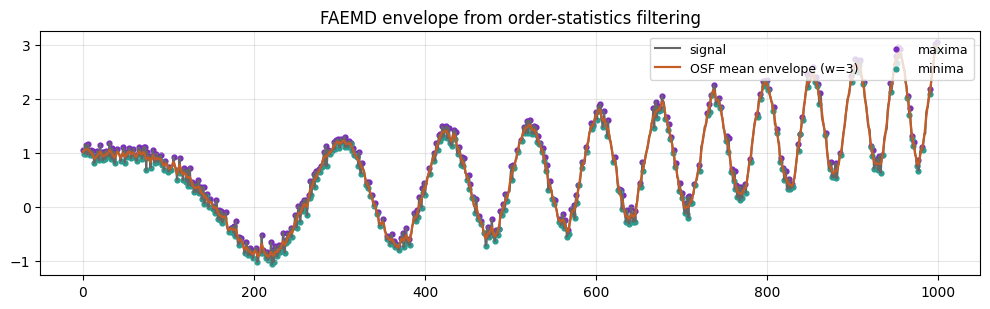

In [2]:
_, signal = test_emd()
t = np.arange(signal.size)

xmax, imax, xmin, imin = extrema(signal)
windows = filter_size1D(imax, imin, window_type=0)
w = int(windows[0])
print("adaptive windows d1..d7 =", windows)
print("selected w =", w)

mean_env = mean_envelope_1d(signal, w)

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(t, signal, color="0.4", label="signal")
ax.plot(t, mean_env, color="#c45c26", lw=1.6, label=f"OSF mean envelope (w={w})")
ax.scatter(imax, xmax, s=12, c="#7b2cbf", label="maxima")
ax.scatter(imin, xmin, s=12, c="#2a9d8f", label="minima")
ax.set_title("FAEMD envelope from order-statistics filtering")
ax.legend(loc="upper right", ncol=2, fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Univariate decomposition

IMFs shape: (4, 1000)
max |recon error|: 4.440892098500626e-16


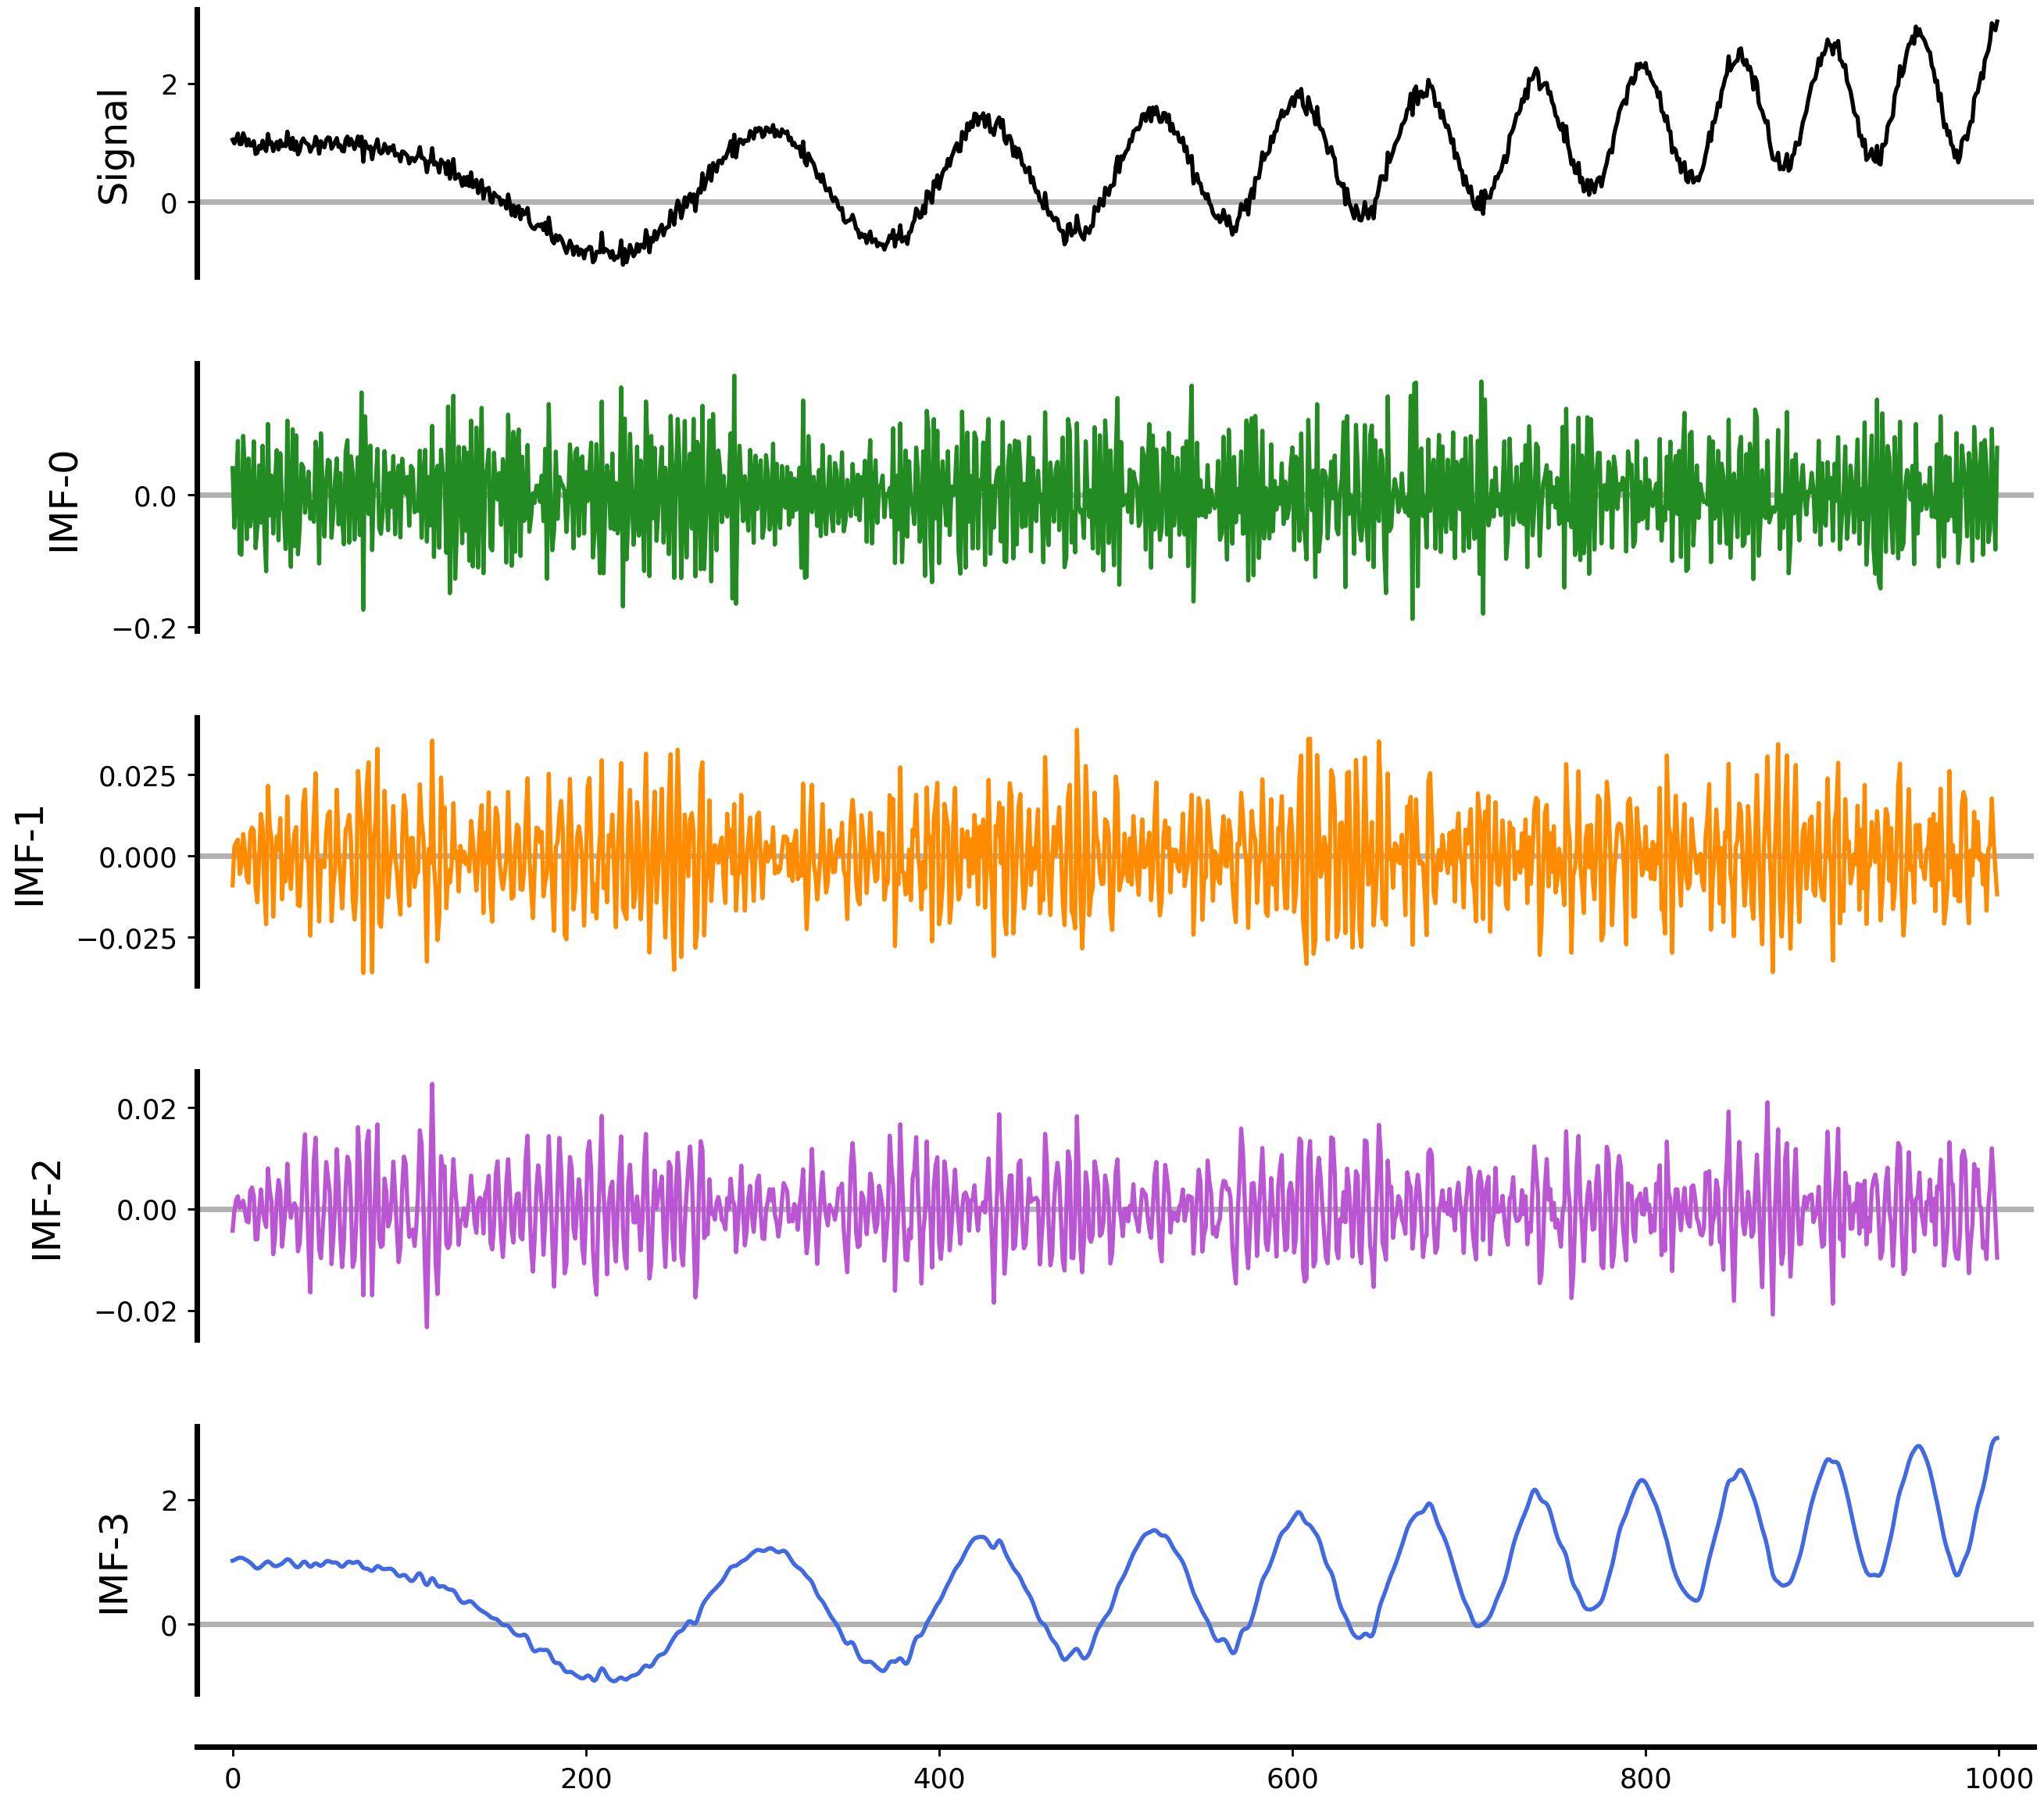

In [3]:
faemd = FAEMD(max_imfs=4, window_type=0)
IMFs = faemd.fit_transform(signal)
print("IMFs shape:", IMFs.shape)
print("max |recon error|:", np.max(np.abs(IMFs.sum(0) - signal)))

fig = plot_IMFs(signal, IMFs, return_figure=True)
plt.show()

## 4. Multivariate 1-D example

Decomposition may be oversifted; filter window size does not increase monotonically.
multivariate IMFs: (3, 1000, 2)


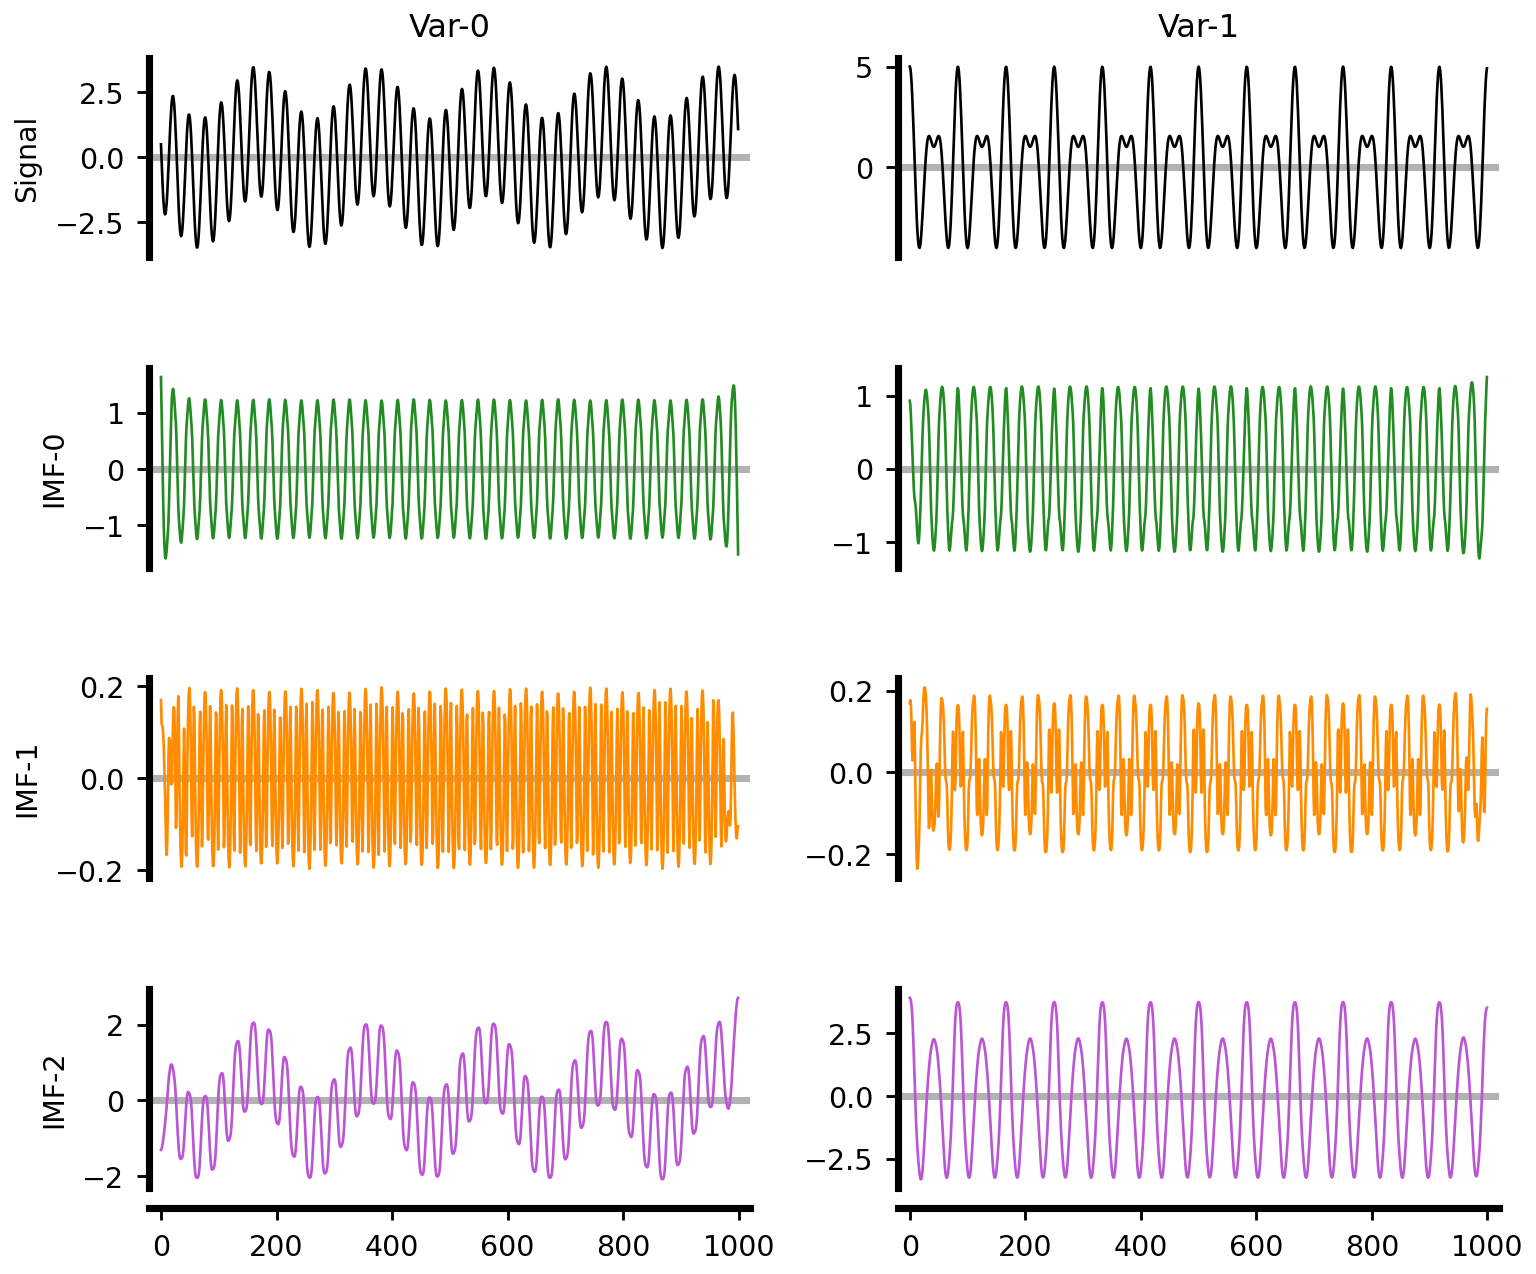

channel-wise recon ok: True


In [4]:
time, mv = test_multivariate_signal(case=1)
IMFs_mv = FAEMD(max_imfs=3).fit_transform(mv)
print("multivariate IMFs:", IMFs_mv.shape)  # (K, seq_len, n_channels)

fig = plot_IMFs(mv, IMFs_mv, return_figure=True)
plt.show()

recon = IMFs_mv.sum(axis=0).T
print("channel-wise recon ok:", np.allclose(recon, mv, atol=1e-6))

## 5. API

```python
from pysdkit import FAEMD

faemd = FAEMD(max_imfs=4, tol=None, window_type=0)
IMFs = faemd.fit_transform(signal)   # (K, L) or (K, L, N)
```

See also `faemd2d.ipynb` and `faemd3d.ipynb` for image / volume variants.